In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
# --- UTAUT2: надёжность шкал ---

def cronbach_alpha(items_df):
    items = items_df.dropna()
    k = items.shape[1]
    return (k / (k - 1)) * (1 - items.var(ddof=1).sum() / items.sum(axis=1).var(ddof=1))

alpha_rows = []
for c in constructs:
    a = cronbach_alpha(da[construct_items[c]])
    
    if a >= 0.9:
        quality = 'отличная'
    elif a >= 0.8:
        quality = 'хорошая'
    elif a >= 0.6:
        quality = 'приемлемая'
    else:
        quality = 'низкая'
    
    alpha_rows.append({
        'Код': c,
        'Конструкт': construct_names[c],
        "Cronbach's α": round(a, 3),
        'Оценка': quality
    })

alpha_df = pd.DataFrame(alpha_rows)
alpha_df

,Код,Конструкт,Cronbach's α,Оценка
0,PU,Воспринимаемая полезность,0.634,приемлемая
1,PEOU,Лёгкость использования,0.414,низкая
2,SI,Социальное влияние,0.651,приемлемая
3,FC,Поддерживающие условия,0.132,низкая
4,HM,Гедоническая мотивация,0.515,низкая
5,PV,Ценность цены,0.698,приемлемая
6,HAB,Привычка,0.895,хорошая
7,BI,Поведенческое намерение,0.664,приемлемая


In [3]:
alpha_if_deleted_rows = []

for c in constructs:
    items = construct_items[c]
    full_alpha = cronbach_alpha(da[items])
    
    for q in items:
        reduced_items = [item for item in items if item != q]
        reduced_alpha = cronbach_alpha(da[reduced_items])
        
        alpha_if_deleted_rows.append({
            'Код': c,
            'Конструкт': construct_names[c],
            'Удалённый пункт': q,
            'α полной шкалы': round(full_alpha, 3),
            'α без пункта': round(reduced_alpha, 3),
            'Δα': round(reduced_alpha - full_alpha, 3)
        })

alpha_if_deleted_df = pd.DataFrame(alpha_if_deleted_rows)
alpha_if_deleted_df.sort_values(['Код', 'Δα'], ascending=[True, False])

,Код,Конструкт,Удалённый пункт,α полной шкалы,α без пункта,Δα
23,BI,Поведенческое намерение,If a suitable online fitness service were ava...,0.664,0.617,-0.047
22,BI,Поведенческое намерение,I plan to make online fitness a regular part...,0.664,0.568,-0.096
21,BI,Поведенческое намерение,I intend to use an online fitness service with...,0.664,0.522,-0.142
10,FC,Поддерживающие условия,I have enough space at home to follow online w...,0.132,0.257,0.125
9,FC,Поддерживающие условия,"I have the necessary devices (smartphone, tabl...",0.132,0.118,-0.014
11,FC,Поддерживающие условия,My internet connection is reliable enough to s...,0.132,-0.120,-0.251
18,HAB,Привычка,Using digital tools or apps to support my exer...,0.895,0.860,-0.035
19,HAB,Привычка,"When I think about exercising, turning to an a...",0.895,0.849,-0.046
20,HAB,Привычка,"I regularly use online resources (videos, apps...",0.895,0.842,-0.053
14,HM,Гедоническая мотивация,"Features like progress tracking, streaks, and ...",0.515,0.505,-0.009


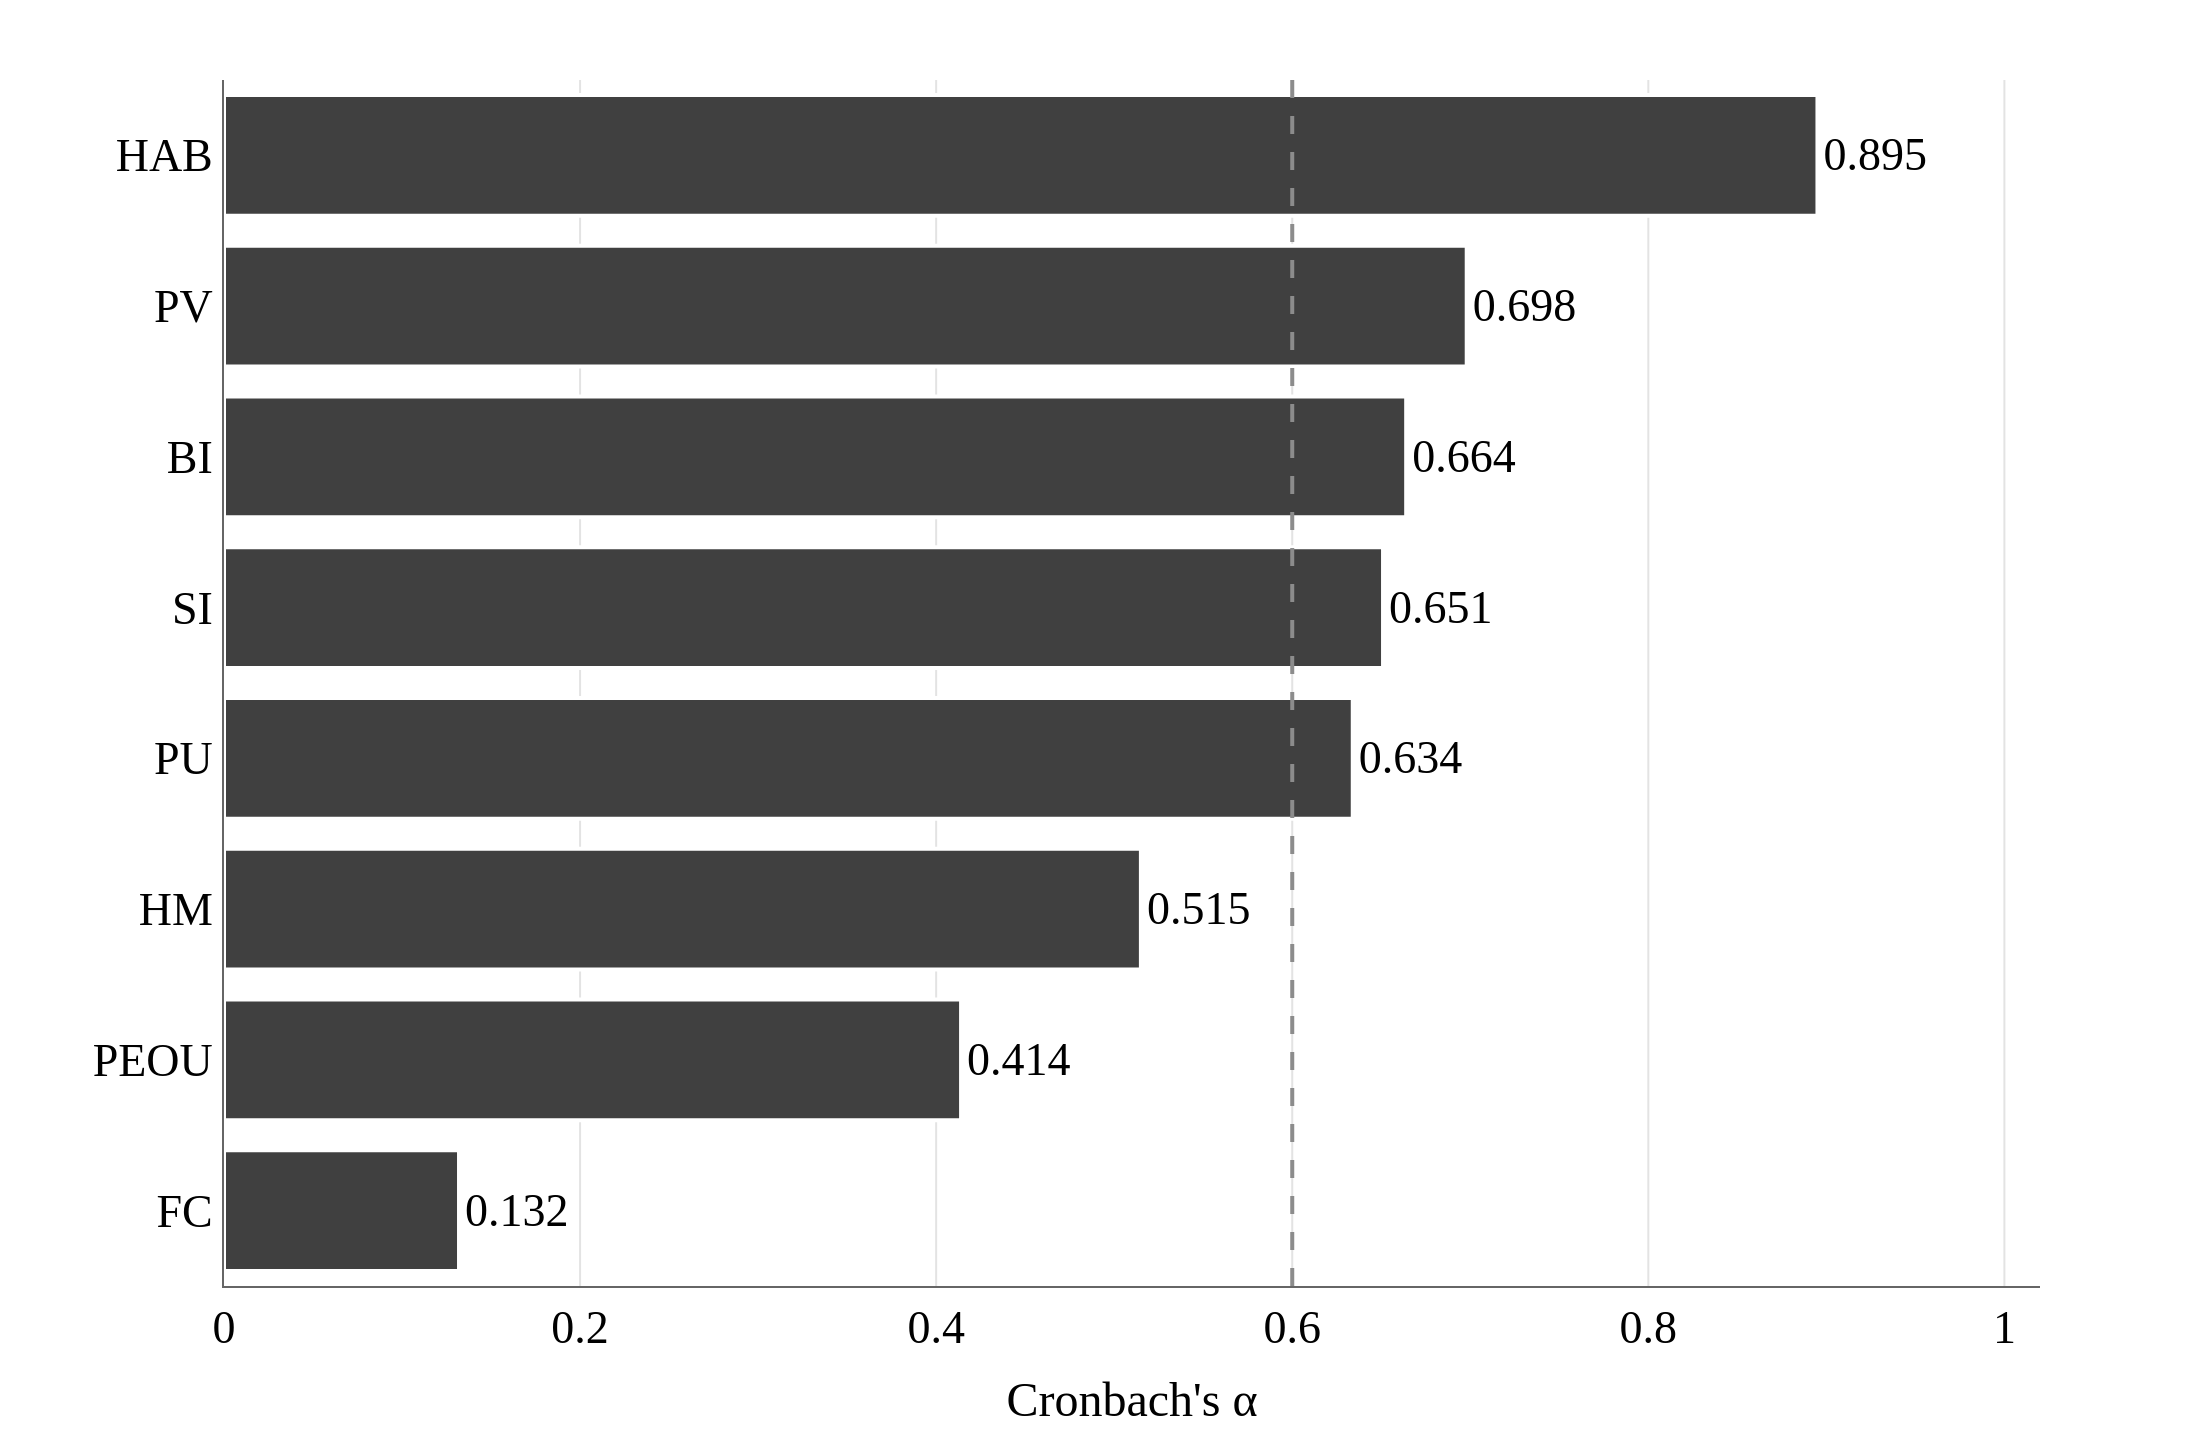

In [4]:
alpha_plot = alpha_df.sort_values("Cronbach's α", ascending=True)

fig = go.Figure(data=[go.Bar(
    y=alpha_plot['Код'],
    x=alpha_plot["Cronbach's α"],
    orientation='h',
    text=[f"{a:.3f}" for a in alpha_plot["Cronbach's α"]],
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{y}</b><br>α = %{x:.3f}<extra></extra>'
)])

fig.add_vline(x=0.6, line_dash='dash', line_color=ACCENT)

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title=dict(text="Cronbach's α", font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, 1.02]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=23),
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    margin=dict(l=80, r=80, t=40, b=70),
    width=1100,
    height=720
)

fig.show()
